In [ ]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import RobustScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

parent_dir = os.path.abspath(os.path.join(os.path.dirname('utils.py'), '..'))
sys.path.append(parent_dir)
import utils as ut  # noqa: E402


In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IN_FEATURES = ['beta', 'Av', 'F115', 'F150', 'F277', 'F444']
OUT_FEATURES = ['flag']
SEED = 42
BATCH_SIZE = 30
EPOCHS = 10000
LR = 1e-4
WD = 1e-2
WEIGHTS = torch.tensor([1.0, 2.0]).to(DEVICE)
RUN = True  # Determines if notebook trains model

params = {
    'num_outputs': 2,
    'dropout': 0.7,
    'scale': 256,
    'input_dim': len(IN_FEATURES),
}

DEVICE  # check device

device(type='cpu')

In [3]:
torch.manual_seed(SEED)

In [ ]:
logged_params = params.copy()
if RUN:
    logged_params['comment'] = input('Enter a comment for this training run: ')
    logged_params['seed'] = SEED
    logged_params['batch size'] = BATCH_SIZE
    logged_params['epochs'] = EPOCHS
    logged_params['learning rate'] = LR
    logged_params['weight decay'] = WD

In [5]:
cwd = Path.cwd()
cutout_dir = cwd.parent / 'data' / 'cutouts'
table_dir = cwd.parent / 'train val test tables'
model_dir = cwd.parent / 'models'

In [6]:
# LOAD TRAIN VAL TABLES

# loop through and read tables
table_dfs = []
for table in table_dir.rglob('*'):
    if table.name == 'test.csv':
        continue
    table_dfs.append(pd.read_csv(table, index_col=0))

# concat segmented dfs to train val sets
train_df = pd.concat(table_dfs[0:-2])
val_df = pd.concat(table_dfs[-2:])

len(pd.concat(table_dfs)), len(train_df), len(val_df)

(438, 342, 96)

In [ ]:
# FILTER FOR CHOSEN FEATURES

# combine dfs while tracking what values came from each for masking
df = pd.concat([train_df, val_df], keys=['train', 'val'])

logged_params['input features'] = IN_FEATURES
logged_params['output features'] = OUT_FEATURES

df = df[IN_FEATURES + OUT_FEATURES]
df.dropna(inplace=True)

In [8]:
#  MASK BAD DATA
fluxes = IN_FEATURES[2:]

# mask unbounded results
df = df[~df[IN_FEATURES].eq(-99).any(axis=1)]

# replace negative fluxes with 0
df[fluxes] = df[fluxes].clip(lower=0)

# split dfs again
train_df = df.xs('train')
val_df = df.xs('val')

len(df), len(train_df), len(val_df)

(434, 340, 94)

In [ ]:
# SCALE DATA

scaler = RobustScaler().set_output(transform='pandas')
fluxes = IN_FEATURES[2:]

train_df[fluxes] = np.log1p(train_df[fluxes])
val_df[fluxes] = np.log1p(val_df[fluxes])

X_train_df = scaler.fit_transform(train_df[IN_FEATURES])
X_val_df = scaler.transform(val_df[IN_FEATURES])

stats_df1 = pd.DataFrame(
    {
        'Median_Train': X_train_df.median(),
        'IQR_Train': X_train_df.quantile(0.75) - X_train_df.quantile(0.25),
    }
)
stats_df2 = pd.DataFrame(
    {
        'Median_Val': X_val_df.median(),
        'IQR_Val': X_val_df.quantile(0.75) - X_val_df.quantile(0.25),
    }
)

stats = pd.concat([stats_df1, stats_df2], axis=1).round(4)
print(stats)

print('\nMax values in Train (scaled):')
print(X_train_df.max())

print('\nMax values in Validation (scaled):')
print(X_val_df.max())

      Median_Train  IQR_Train  Median_Val  IQR_Val
beta           0.0        1.0     -0.0120   0.9228
Av             0.0        1.0     -0.0202   1.0529
F115          -0.0        1.0     -0.1340   1.0332
F150          -0.0        1.0      0.0302   1.0099
F277           0.0        1.0      0.1450   0.8705
F444           0.0        1.0      0.1851   1.0686

Max values in Train (scaled):
beta    2.313429
Av      2.401713
F115    1.739643
F150    1.744852
F277    2.444806
F444    2.436946
dtype: float64

Max values in Validation (scaled):
beta    1.937698
Av      2.116170
F115    2.321414
F150    2.553395
F277    3.478362
F444    3.316698
dtype: float64


In [10]:
# CONVERT TO TENSORS

X_train = torch.tensor(train_df[IN_FEATURES].values)
X_val = torch.tensor(val_df[IN_FEATURES].values)
y_train = torch.tensor(train_df['flag'].values)
y_val = torch.tensor(val_df['flag'].values)

In [ ]:
class FCBlock(nn.Module):
    def __init__(self, input_dim, dropout, num_outputs, scale=32):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(input_dim, scale),
            nn.BatchNorm1d(scale),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            # nn.Linear(scale, scale//2),
            # nn.BatchNorm1d(scale//2),
            # nn.ReLU(inplace=True),
            # nn.Dropout(dropout),
            nn.Linear(scale, scale // 4),
            nn.BatchNorm1d(scale // 4),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(scale // 4, num_outputs),
        )

    def forward(self, x):
        return self.block(x)

In [ ]:
class GalaxyClassifier(nn.Module):
    "Full Galaxy Classifier network."

    def __init__(
        self,
        num_outputs: int = 1,
        input_dim: int = 8,
        scale: int = 4,
        dropout: float = 0.4,
        **kwargs,
    ):

        super().__init__()
        self.fc = FCBlock(
            input_dim=input_dim,
            dropout=dropout,
            num_outputs=num_outputs,
            scale=scale,
        )

    def forward(self, x):
        x = self.fc(x)

        return x

In [ ]:
loss_func = torch.nn.CrossEntropyLoss(weight=WEIGHTS)
model = GalaxyClassifier(**params).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

logged_params['loss function'] = str(loss_func)
logged_params['model'] = str(model)
logged_params['optimizer'] = str(optimizer)

model_path = None
if model_path is not None:
    checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)

    # 3. Restore the states
    model.load_state_dict(checkpoint['model_state_dict'])

    # 4. Restore metadata variables
    start_epoch = checkpoint['epoch']
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']
else:
    start_epoch = 1
    train_losses = []
    val_losses = []

In [ ]:
# 'dummy' data points to test if model takes and gives inputs / outputs
# of correct shape without crashing
dummy = torch.randn(8, len(IN_FEATURES)).to(DEVICE)
out = model(dummy)
print(f'Output shape: {out.shape}')

# calculate number of model parameters
num_params = sum(p.numel() for p in model.parameters())
logged_params['num params'] = num_params

print(f'Params: {num_params:,}')

Output shape: torch.Size([8, 2])
Params: 19,010


In [ ]:
# sets the number of galaxies used in training
train_size = len(X_train)
val_size = len(X_val)

# set up minibatches
train_data = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=BATCH_SIZE, shuffle=True
)

val_data = torch.utils.data.TensorDataset(X_val, y_val)
val_loader = torch.utils.data.DataLoader(
    val_data, batch_size=BATCH_SIZE, shuffle=True
)

In [ ]:
from tqdm.auto import trange

if RUN:
    train_losses = []
    val_losses = []

    # Training Loop ---------------------------------------------------------------------------------------
    for _epoch in trange(EPOCHS, desc='Epochs', smoothing=0):
        model.train()
        running_loss = 0
        num_done = 0

        for data, labels in train_loader:
            optimizer.zero_grad()
            if data.ndim == 1:
                data = data.unsqueeze(1)
            data = data.float()
            outputs = model(data)
            labels = labels.long()  # FOR CLASSIFICATION
            loss = loss_func(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * data.size(0)
            num_done += data.size(0)
            running_avg_loss = (running_loss / num_done) ** 0.5

        train_losses.append(running_avg_loss)  # track loss only once per epoch
        # scheduler.step()

        # Compute Validation Accuracy ----------------------------------------------------------------------
        model.eval()
        running_loss = 0
        num_done = 0

        with torch.no_grad():
            for data, labels in val_loader:
                if data.ndim == 1:
                    data = data.unsqueeze(1)
                data = data.float()

                outputs = model(data)
                labels = labels.long()
                loss = loss_func(outputs, labels)

                running_loss += loss.item() * data.size(0)
                num_done += data.size(0)

                running_avg_val_loss = (running_loss / num_done) ** 0.5

            val_losses.append(running_avg_val_loss)

Epochs:   0%|          | 0/10000 [00:00<?, ?it/s]

In [ ]:
if RUN:
    model.eval()

    corr = 0
    tot = 0

    preds = []
    lbls = []

    with torch.no_grad():
        for data, labels in val_loader:
            labels = labels.long()
            if data.ndim == 1:
                data = data.unsqueeze(1)
            data = data.float()
            outputs = model(data)

            tot += data.size(0)
            predictions = torch.argmax(outputs, dim=1)
            corr += (predictions == labels).float().sum()

            preds.extend(predictions.tolist())
            lbls.extend(labels.tolist())

    resdf = pd.DataFrame()
    resdf['labels'] = lbls
    resdf['predictions'] = preds
    resdf['correct'] = resdf['labels'] == resdf['predictions']

    confusion_matrix = pd.crosstab(
        resdf['labels'],
        resdf['predictions'],
        rownames=['Actual'],
        colnames=['Predicted'],
    )

    # index with actual, predicted
    try:
        false_pos = confusion_matrix.loc[0, 1]
        false_neg = confusion_matrix.loc[1, 0]
        true_pos = confusion_matrix.loc[1, 1]
        true_neg = confusion_matrix.loc[0, 0]

        purity = true_pos / (true_pos + false_pos)
        completeness = true_pos / (true_pos + false_neg)

        logged_params['purity (dusty)'] = purity
        logged_params['completeness (dusty)'] = completeness
    except Exception:
        pass

    accuracy = float(corr / tot)

    logged_params['accuracy'] = accuracy
    logged_params['confusion matrix'] = str(confusion_matrix)
    logged_params['last validation loss'] = val_losses[-1]

In [ ]:
if RUN:
    name = f'model_{val_losses[-1]:.3f}.pth'
    # save the model along with loss curve data so I can test different parameters and keep the best one
    torch.save(
        {
            'epoch': EPOCHS + start_epoch,
            'model_state_dict': model.state_dict(),
            'train_losses': train_losses,
            'optimizer_state_dict': optimizer.state_dict(),
            'val_losses': val_losses,
        },
        model_dir / 'fc' / f'model_{val_losses[-1]:.3f}.pth',
    )

    # also log the run
    logger = ut.RunLogger(filepath=cwd.parent / 'logs' / 'fc_log.json')
    logger.log_run(logged_params)

purity:  0.5454545454545454 completeness:  0.75
accuracy:  0.7021276354789734


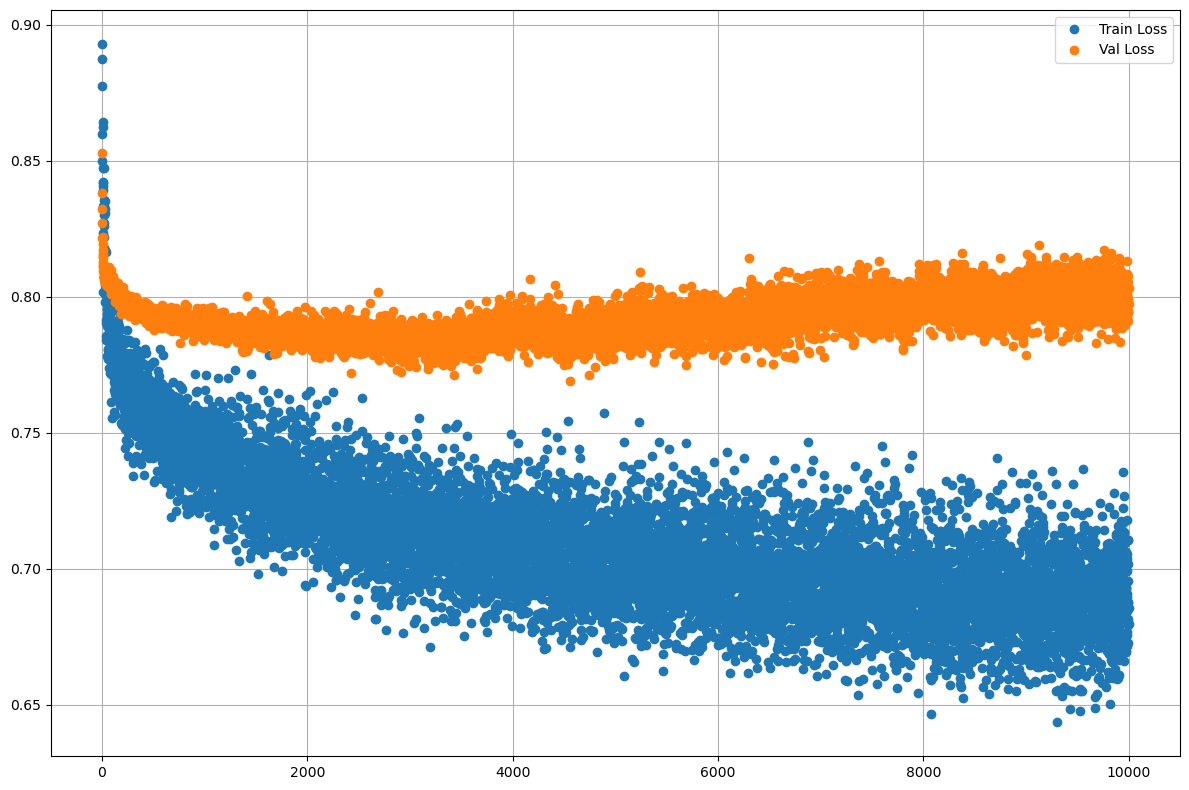

In [ ]:
if RUN:
    import contextlib

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.plot(train_losses, label='Train Loss', marker='o', linestyle='None')
    ax.plot(val_losses, label='Val Loss', marker='o', linestyle='None')
    ax.grid()
    ax.legend()
    fig.tight_layout()

    with contextlib.suppress(BaseException):
        print('purity: ', purity, 'completeness: ', completeness)
    print('accuracy: ', accuracy)

In [ ]:
params = {'num_outputs': 2, 'dropout': 0.6, 'scale': 32, 'input_dim': 6}
model = GalaxyClassifier(**params)
model_path = r'C:\Users\harty\Code\Galaxy-Classifier\Summer Research\models\fc\model_0.788.pth'